<a href="https://colab.research.google.com/github/phatnguyen63441-ai/TH-Deep-Lab3/blob/main/B%C3%A0i_t%E1%BA%ADp_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bài 1 — ANN nhận dạng ảnh CIFAR10

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# 1. Load dataset CIFAR10
print("Loading CIFAR10 data...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalize image data to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Convert labels to one-hot encoding
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

# 4. Build the ANN model
model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 5. Train the model
print("\nStarting training...")
history = model.fit(x_train, y_train_onehot, epochs=15, batch_size=64,
                    validation_data=(x_test, y_test_onehot))

# 6. Evaluate accuracy on test set
test_loss, test_acc = model.evaluate(x_test, y_test_onehot, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

Loading CIFAR10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.3252 - loss: 1.8627 - val_accuracy: 0.3666 - val_loss: 1.7866
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3993 - loss: 1.6702 - val_accuracy: 0.4092 - val_loss: 1.6500
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.4343 - loss: 1.5818 - val_accuracy: 0.4442 - val_loss: 1.5385
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4552 - loss: 1.5209 - val_accuracy: 0.4540 - val_loss: 1.5428
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4699 - loss: 1.4806 - val_accuracy: 0.4744 - val_loss: 1.4664
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4791 - loss: 1.4488 - val_accuracy: 0.4608 - val_loss: 1.5104
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4930 - loss: 1.4136 - val_accuracy: 0.4706 - val_loss: 1.4792
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.

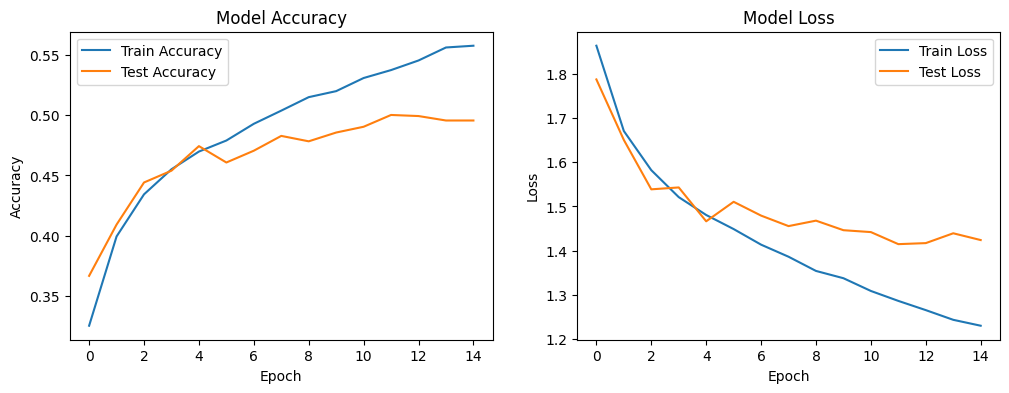

In [ ]:
# 7. Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


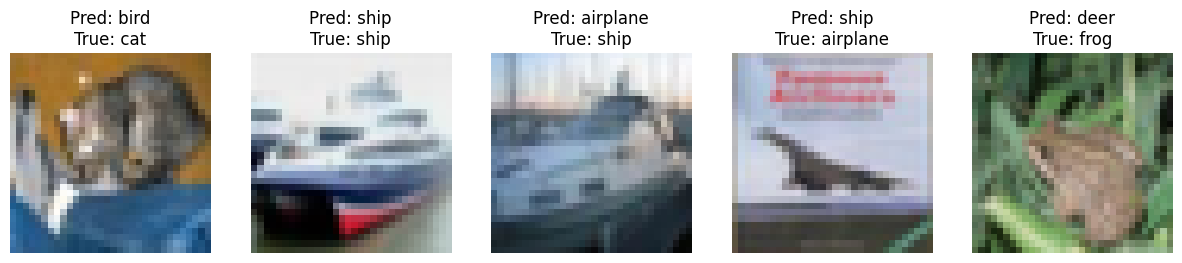

In [ ]:
# 8. Predict some test images and display results
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predictions = model.predict(x_test[:5])

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i])
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i][0]
    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}")
    plt.axis('off')
plt.show()

Bài 2 — ANN nhận dạng chữ số MNIST

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Load dataset MNIST
print("Loading MNIST data...")
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Chuẩn hóa dữ liệu ảnh về khoảng [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Chuyển label sang one-hot encoding
y_train_oh = to_categorical(y_train, 10)
y_test_oh = to_categorical(y_test, 10)

# 4. Xây dựng mô hình ANN
model_mnist = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Reshape 28x28 thành vector 784
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mnist.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_mnist.summary()

# 5. Huấn luyện model
print("\nStarting training MNIST model...")
history_mnist = model_mnist.fit(x_train, y_train_oh, epochs=10, batch_size=128,
                                validation_data=(x_test, y_test_oh))

# 6. Đánh giá accuracy trên tập test
test_loss, test_acc = model_mnist.evaluate(x_test, y_test_oh, verbose=2)
print(f"\nMNIST Test Accuracy: {test_acc:.4f}")

Loading MNIST data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)


Starting training MNIST model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9352 - loss: 0.2231 - val_accuracy: 0.9607 - val_loss: 0.1233
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9744 - loss: 0.0830 - val_accuracy: 0.9758 - val_loss: 0.0771
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9833 - loss: 0.0526 - val_accuracy: 0.9778 - val_loss: 0.0679
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9879 - loss: 0.0371 - val_accuracy: 0.9797 - val_loss: 0.0679
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9914 - loss: 0.0263 - val_accuracy: 0.9784 - val_loss: 0.0751
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9930 - loss: 0.0220 - val_accuracy: 0.9764 - val_loss: 0.0803
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9942 - loss: 0.0177 - val_accuracy: 0.9760 - val_loss: 0.0871
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accura

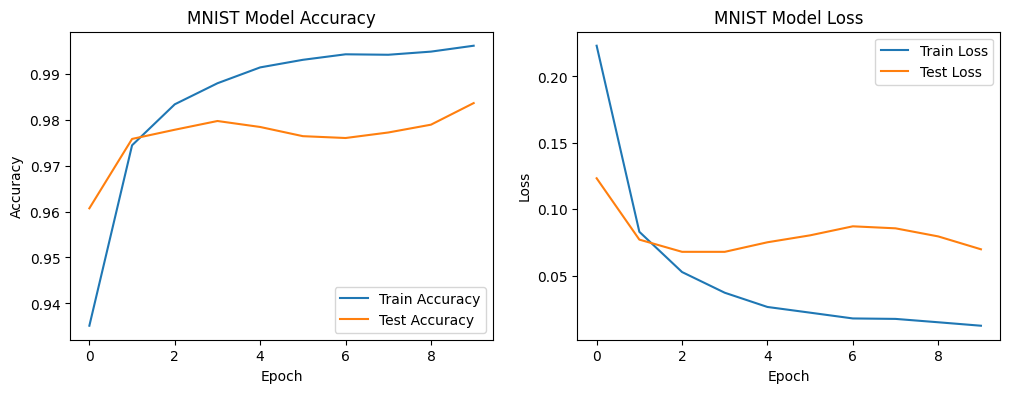

In [ ]:
# 7. Vẽ biểu đồ accuracy và loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Train Accuracy')
plt.plot(history_mnist.history['val_accuracy'], label='Test Accuracy')
plt.title('MNIST Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'], label='Train Loss')
plt.plot(history_mnist.history['val_loss'], label='Test Loss')
plt.title('MNIST Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Confusion Matrix:


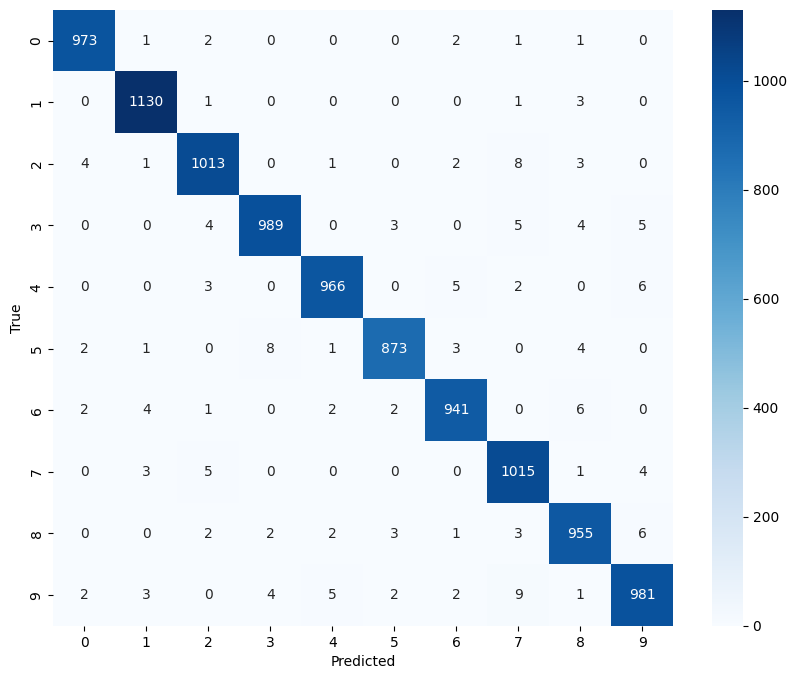

In [ ]:
# 8. Hiển thị confusion matrix và classification report
y_pred = model_mnist.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

print("\nConfusion Matrix:")
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

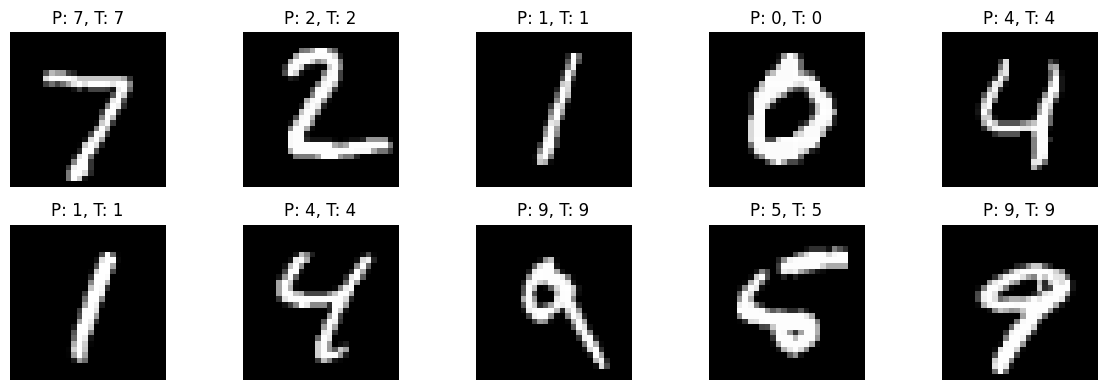

In [ ]:
# 9. Dự đoán một vài ảnh test
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"P: {y_pred_classes[i]}, T: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Bài 4 — ANN dự đoán thu nhập Adult Dataset

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải và đọc dữ liệu Adult dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, names=columns, sep=',', skipinitialspace=True)

# 2. Xử lý missing values (trong bộ này ký hiệu là '?')
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# 3. Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Tách X, y (income là biến mục tiêu)
X = df.drop('income', axis=1).values
y = df['income'].values

# 4. Tách tập train/test và chuẩn hóa dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Xây dựng mô hình ANN
model_adult = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_adult.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Huấn luyện model
history_adult = model_adult.fit(X_train, y_train, epochs=20, batch_size=64,
                                validation_data=(X_test, y_test), verbose=1)

# 7. Đánh giá và hiển thị kết quả
loss, acc = model_adult.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8164 - loss: 0.3908 - val_accuracy: 0.8394 - val_loss: 0.3457
Epoch 2/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8415 - loss: 0.3377 - val_accuracy: 0.8452 - val_loss: 0.3347
Epoch 3/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8454 - loss: 0.3310 - val_accuracy: 0.8452 - val_loss: 0.3325
Epoch 4/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8450 - loss: 0.3280 - val_accuracy: 0.8473 - val_loss: 0.3320
Epoch 5/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8480 - loss: 0.3251 - val_accuracy: 0.8488 - val_loss: 0.3305
Epoch 6/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8470 - loss: 0.3231 - val_accuracy: 0.8483 - val_loss: 0.3274
Epoch 7/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8489 - loss: 0.3214 - val_accuracy: 0.8463 - val_loss: 0.3297
Epoch 8/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8495 - loss: 0.3195 - val_accuracy: 0.8500 - val_

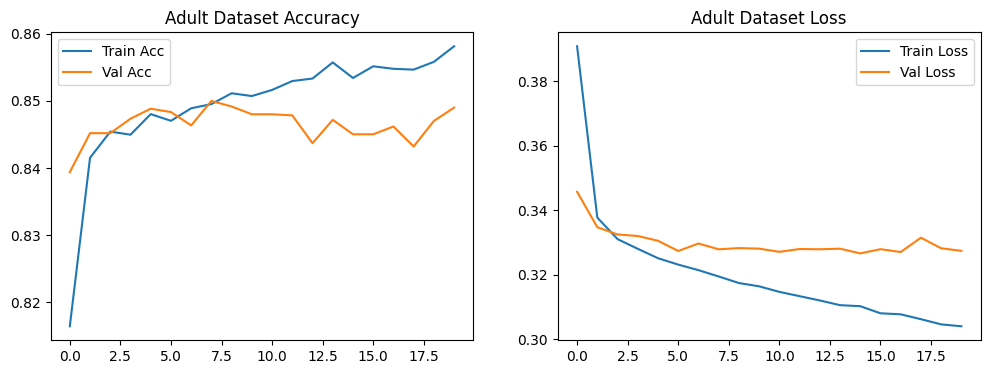

In [ ]:
# 8. Biểu đồ Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_adult.history['accuracy'], label='Train Acc')
plt.plot(history_adult.history['val_accuracy'], label='Val Acc')
plt.title('Adult Dataset Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adult.history['loss'], label='Train Loss')
plt.plot(history_adult.history['val_loss'], label='Val Loss')
plt.title('Adult Dataset Loss')
plt.legend()
plt.show()

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4503
           1       0.73      0.64      0.68      1530

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.84      0.85      0.85      6033



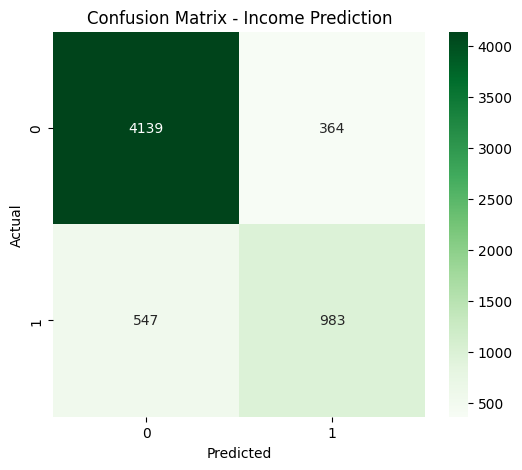

In [ ]:
# 9. Confusion Matrix & Classification Report
y_pred_prob = model_adult.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Income Prediction')
plt.show()

Bài 5 — ANN đánh giá chất lượng xe ô tô

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải và đọc dữ liệu Car Evaluation dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df_car = pd.read_csv(url, names=columns)

# 2. Tiền xử lý dữ liệu
# Mã hóa các thuộc tính categorical sang dạng số
le = LabelEncoder()
for col in df_car.columns:
    df_car[col] = le.fit_transform(df_car[col])

# Lưu lại danh sách các lớp để hiển thị kết quả dự đoán
class_names_car = le.classes_

# Tách X (đặc trưng) và y (nhãn)
X = df_car.drop('class', axis=1).values
y = df_car['class'].values

# Chuyển nhãn sang One-hot encoding vì có 4 lớp
y_oh = tf.keras.utils.to_categorical(y, num_classes=4)

# 3. Tách tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_oh, test_size=0.2, random_state=42)

# 4. Xây dựng mô hình ANN
model_car = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 lớp: unacc, acc, good, vgood
])

model_car.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Huấn luyện model
print("Starting training Car Evaluation model...")
history_car = model_car.fit(X_train, y_train, epochs=50, batch_size=16,
                            validation_data=(X_test, y_test), verbose=0)

# 6. Đánh giá model
loss, acc = model_car.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training Car Evaluation model...

Test Accuracy: 0.9624


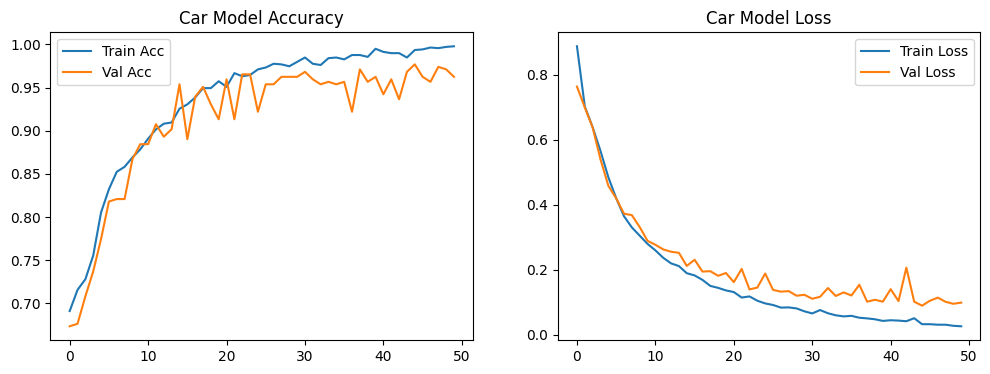

In [ ]:
# 7. Vẽ biểu đồ Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_car.history['accuracy'], label='Train Acc')
plt.plot(history_car.history['val_accuracy'], label='Val Acc')
plt.title('Car Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_car.history['loss'], label='Train Loss')
plt.plot(history_car.history['val_loss'], label='Val Loss')
plt.title('Car Model Loss')
plt.legend()
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


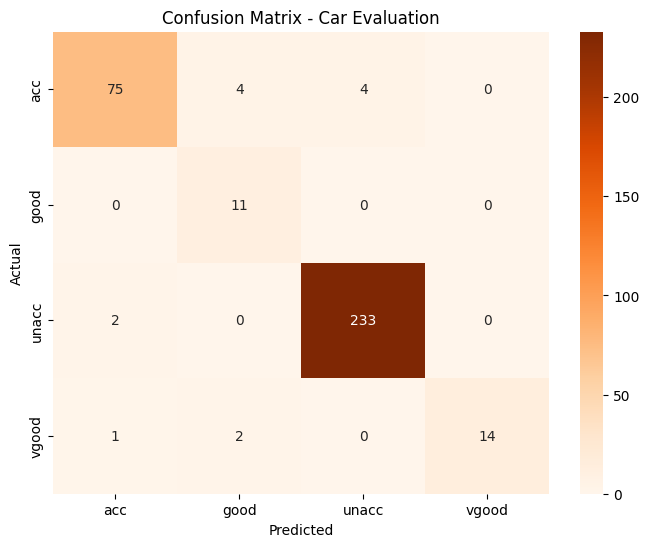

In [ ]:
# 8. Confusion Matrix
y_pred = model_car.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_car, yticklabels=class_names_car)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Car Evaluation')
plt.show()